# Классификация CC50 относительно медианного значения

В этом ноутбуке решается задача бинарной классификации.

Цель модели -> определить, превышает ли значение `CC50, mM` медианное значение по выборке.

Целевая переменная строится следующим образом:

- `0` -> `CC50, mM` меньше либо равно медиане
- `1` -> `CC50, mM` больше медианы

Для обучения используются молекулярные дескрипторы.

Из признаков исключаются служебные столбцы и все целевые переменные:
`IC50, mM`, `CC50, mM`, `SI`.

Это необходимо, чтобы не допустить утечки данных.

## Импорты

In [92]:
# Библиотеки для работы с данными
import pandas as pd

# Для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Разделение данных и отчет классификации
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# Загрузка конфигурации проекта
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.config import (
    METRICS_DIR,
    PREDICTIONS_DIR,
    RANDOM_STATE,
    TARGET_CC50,
    TEST_SIZE,
)

# Загрузка данных
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.data_loader import load_coursework_dataset

# Подготовка признаков и целевой переменной
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.preprocessing import (
    build_cc50_above_median_target,
    build_features,
    preprocess_features,
)

# Фабрика моделей
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.model_factory import get_classification_models

# Запуск экспериментов
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.experiment_runner import run_classification_experiment

# Визуализация результатов
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.plotting import (
    plot_classification_results,
)

## Загрузка данных

Загрузим исходный датасет из Excel-файла.

In [93]:
df = load_coursework_dataset()

df.head()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


## Подготовка признаков и целевой переменной

Сформируем матрицу признаков `X` и бинарную целевую переменную `y`.

В качестве целевой переменной используется признак:

`CC50, mM > median(CC50, mM)`

Также отдельно сохраним медианное значение `CC50, mM`, чтобы явно показать порог классификации.

In [94]:
X = build_features(df)

y = build_cc50_above_median_target(df)

cc50_median = df[TARGET_CC50].median()

print(f"Размер исходной матрицы признаков X: {X.shape}")
print(f"Размер целевой переменной y: {y.shape}")
print(f"Медианное значение {TARGET_CC50}: {cc50_median:.4f}")

Размер исходной матрицы признаков X: (1001, 210)
Размер целевой переменной y: (1001,)
Медианное значение CC50, mM: 411.0393


## Распределение классов

Проверим, насколько сбалансированы классы.

Так как целевая переменная построена относительно медианы, ожидается достаточно равномерное распределение классов.

In [95]:
class_distribution = (
    y.value_counts()
    .sort_index()
    .rename_axis("class")
    .reset_index(name="count")
)

class_distribution["share"] = class_distribution["count"] / class_distribution["count"].sum()

class_distribution

,class,count,share
0,0,502,0.501499
1,1,499,0.498501


## Предобработка признаков

По итогам EDA выполним очистку признакового пространства.

Удалим:

- константные признаки, у которых во всех строках одно и то же значение
- почти константные признаки, где одно значение встречается минимум в 99% строк
- сильно коррелирующие признаки, если абсолютная Spearman-корреляция между двумя признаками не ниже 0.90

Целевую переменную не изменяем на этом этапе.

In [96]:
X_clean, preprocessing_report = preprocess_features(X)

print(f"Размер матрицы признаков до обработки: {X.shape}")
print(f"Размер матрицы признаков после обработки: {X_clean.shape}")
print(f"Удалено константных признаков: {len(preprocessing_report['constant_features'])}")
print(f"Удалено почти константных признаков: {len(preprocessing_report['near_constant_features'])}")
print(f"Удалено сильно коррелирующих признаков: {len(preprocessing_report['highly_correlated_features'])}")
print(f"Всего удалено признаков: {len(preprocessing_report['removed_features'])}")

Размер матрицы признаков до обработки: (1001, 210)
Размер матрицы признаков после обработки: (1001, 134)
Удалено константных признаков: 18
Удалено почти константных признаков: 15
Удалено сильно коррелирующих признаков: 43
Всего удалено признаков: 76


In [97]:
preprocessing_summary = pd.DataFrame(
    {
        "step": [
            "constant_features",
            "near_constant_features",
            "highly_correlated_features",
            "removed_features",
            "remaining_features",
        ],
        "count": [
            len(preprocessing_report["constant_features"]),
            len(preprocessing_report["near_constant_features"]),
            len(preprocessing_report["highly_correlated_features"]),
            len(preprocessing_report["removed_features"]),
            len(preprocessing_report["remaining_features"]),
        ],
    }
)

preprocessing_summary

,step,count
0,constant_features,18
1,near_constant_features,15
2,highly_correlated_features,43
3,removed_features,76
4,remaining_features,134


## Подготовка моделей классификации

Для сравнения используем несколько моделей бинарной классификации:

- DummyClassifier
- Logistic Regression
- KNN
- SVC
- Random Forest
- Extra Trees
- HistGradientBoosting
- CatBoost

`DummyClassifier` необходим как базовая модель для проверки, действительно ли остальные модели находят полезные закономерности в данных.

In [98]:
classification_models = get_classification_models()

classification_models.keys()

dict_keys(['dummy_most_frequent', 'logistic_regression', 'knn', 'svc_rbf', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'catboost'])

## Запуск эксперимента

Обучим модели на предобработанных признаках.

Для оценки качества используем:

- `accuracy`
- `balanced_accuracy`
- `precision`
- `recall`
- `f1`
- `roc_auc`

Основной метрикой для выбора модели будем считать `F1`, так как она учитывает баланс между precision и recall.

In [99]:
cc50_classification_results, cc50_fitted_models = run_classification_experiment(
    X=X_clean,
    y=y,
    models=classification_models,
)

cc50_classification_results["feature_set"] = "preprocessed_features"
cc50_classification_results["target"] = "cc50_above_median"

cc50_classification_results

,model,cv_f1_mean,cv_f1_std,train_rows,test_rows,fit_time_sec,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,feature_set,target
0,svc_rbf,0.756798,0.012408,800,201,1.679873,0.751244,0.751634,0.715517,0.83,0.768519,0.820594,preprocessed_features,cc50_above_median
1,hist_gradient_boosting,0.743577,0.015917,800,201,1.884200,0.751244,0.751535,0.723214,0.81,0.764151,0.852178,preprocessed_features,cc50_above_median
2,catboost,0.749509,0.011714,800,201,4.097684,0.741294,0.741584,0.714286,0.80,0.754717,0.842574,preprocessed_features,cc50_above_median
3,knn,0.754333,0.025644,800,201,0.148451,0.726368,0.726683,0.699115,0.79,0.741784,0.810545,preprocessed_features,cc50_above_median
4,extra_trees,0.751237,0.014780,800,201,0.542083,0.721393,0.721683,0.696429,0.78,0.735849,0.842277,preprocessed_features,cc50_above_median
5,logistic_regression,0.752303,0.022811,800,201,1.607020,0.701493,0.701782,0.678571,0.76,0.716981,0.822772,preprocessed_features,cc50_above_median
6,random_forest,0.756684,0.011693,800,201,0.738055,0.691542,0.691931,0.663793,0.77,0.712963,0.836832,preprocessed_features,cc50_above_median
7,dummy_most_frequent,0.000000,0.000000,800,201,2.036244,0.502488,0.500000,0.000000,0.00,0.000000,0.500000,preprocessed_features,cc50_above_median


## Сохранение метрик

Сохраним таблицу с результатами эксперимента.

In [100]:
cc50_classification_results.to_csv(
    METRICS_DIR / "classification_cc50_median_metrics.csv",
    index=False,
)

cc50_classification_results

,model,cv_f1_mean,cv_f1_std,train_rows,test_rows,fit_time_sec,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,feature_set,target
0,svc_rbf,0.756798,0.012408,800,201,1.679873,0.751244,0.751634,0.715517,0.83,0.768519,0.820594,preprocessed_features,cc50_above_median
1,hist_gradient_boosting,0.743577,0.015917,800,201,1.884200,0.751244,0.751535,0.723214,0.81,0.764151,0.852178,preprocessed_features,cc50_above_median
2,catboost,0.749509,0.011714,800,201,4.097684,0.741294,0.741584,0.714286,0.80,0.754717,0.842574,preprocessed_features,cc50_above_median
3,knn,0.754333,0.025644,800,201,0.148451,0.726368,0.726683,0.699115,0.79,0.741784,0.810545,preprocessed_features,cc50_above_median
4,extra_trees,0.751237,0.014780,800,201,0.542083,0.721393,0.721683,0.696429,0.78,0.735849,0.842277,preprocessed_features,cc50_above_median
5,logistic_regression,0.752303,0.022811,800,201,1.607020,0.701493,0.701782,0.678571,0.76,0.716981,0.822772,preprocessed_features,cc50_above_median
6,random_forest,0.756684,0.011693,800,201,0.738055,0.691542,0.691931,0.663793,0.77,0.712963,0.836832,preprocessed_features,cc50_above_median
7,dummy_most_frequent,0.000000,0.000000,800,201,2.036244,0.502488,0.500000,0.000000,0.00,0.000000,0.500000,preprocessed_features,cc50_above_median


## График сравнения моделей

Построим график сравнения моделей по метрике `F1`.

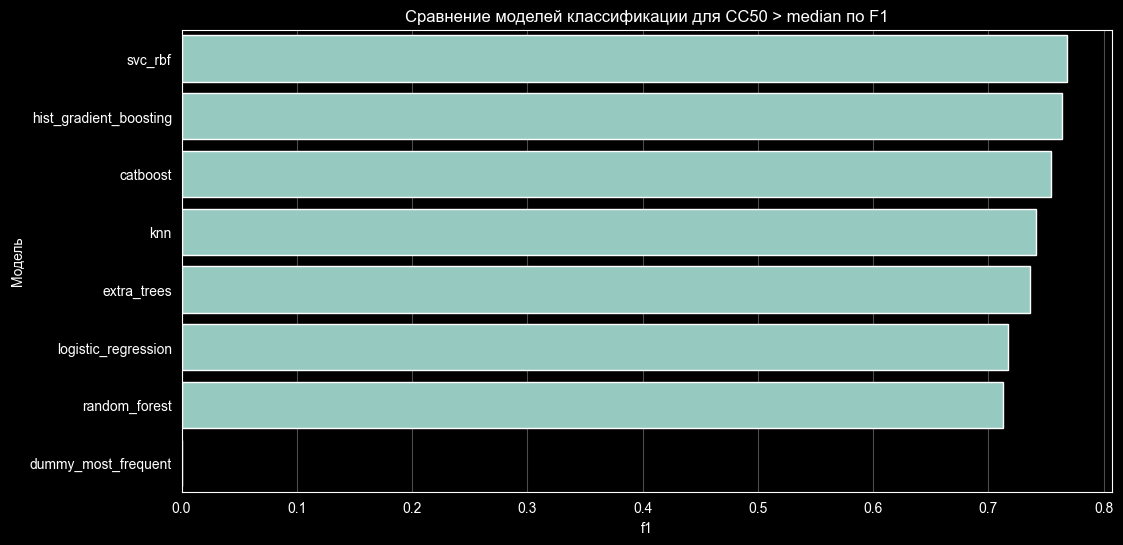

In [101]:
plot_classification_results(
    results_df=cc50_classification_results,
    metric="f1",
    title="Сравнение моделей классификации для CC50 > median по F1",
)

## Выбор лучшей модели

Выберем модель с максимальным значением `F1`.

Дополнительно посмотрим:

- набор признаков
- целевую переменную
- accuracy
- balanced accuracy
- precision
- recall
- F1
- ROC-AUC

In [102]:
best_result = cc50_classification_results.iloc[0]

best_result

model                              svc_rbf
cv_f1_mean                        0.756798
cv_f1_std                         0.012408
train_rows                             800
test_rows                              201
fit_time_sec                      1.679873
accuracy                          0.751244
balanced_accuracy                 0.751634
precision                         0.715517
recall                                0.83
f1                                0.768519
roc_auc                           0.820594
feature_set          preprocessed_features
target                   cc50_above_median
Name: 0, dtype: object

## Вывод названия лучшей модели

In [103]:
best_model_name = best_result["model"]

print(f"Лучшая модель: {best_model_name}")
print(f"Набор признаков: {best_result['feature_set']}")
print(f"Целевая переменная: {best_result['target']}")
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"Balanced accuracy: {best_result['balanced_accuracy']:.4f}")
print(f"Precision: {best_result['precision']:.4f}")
print(f"Recall: {best_result['recall']:.4f}")
print(f"F1: {best_result['f1']:.4f}")
print(f"ROC-AUC: {best_result['roc_auc']:.4f}")

Лучшая модель: svc_rbf
Набор признаков: preprocessed_features
Целевая переменная: cc50_above_median
Accuracy: 0.7512
Balanced accuracy: 0.7516
Precision: 0.7155
Recall: 0.8300
F1: 0.7685
ROC-AUC: 0.8206


## Получение лучшей обученной модели

Получим лучшую модель из словаря обученных моделей.

In [104]:
best_model = cc50_fitted_models[best_model_name]

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

## Получение предсказаний лучшей модели

Повторим разбиение на train/test с теми же параметрами, которые используются внутри эксперимента.

Это нужно, чтобы получить `y_test` и предсказания лучшей модели для анализа ошибок.

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

y_pred = best_model.predict(X_test)

best_predictions = pd.DataFrame(
    {
        "y_true": y_test,
        "y_pred": y_pred,
    }
)

best_predictions.to_csv(
    PREDICTIONS_DIR / "classification_cc50_median_best_predictions.csv",
    index=False,
)

best_predictions.head()

,y_true,y_pred
371,1,1
865,0,0
75,0,0
556,0,0
184,1,0


## Отчет классификации

Посмотрим precision, recall и F1 отдельно по каждому классу.

In [106]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "CC50 <= median",
            "CC50 > median",
        ],
    )
)

                precision    recall  f1-score   support

CC50 <= median       0.80      0.67      0.73       101
 CC50 > median       0.72      0.83      0.77       100

      accuracy                           0.75       201
     macro avg       0.76      0.75      0.75       201
  weighted avg       0.76      0.75      0.75       201



## Матрица ошибок

Построим матрицу ошибок для лучшей модели.

Она покажет, сколько объектов каждого класса модель классифицировала правильно и сколько перепутала.

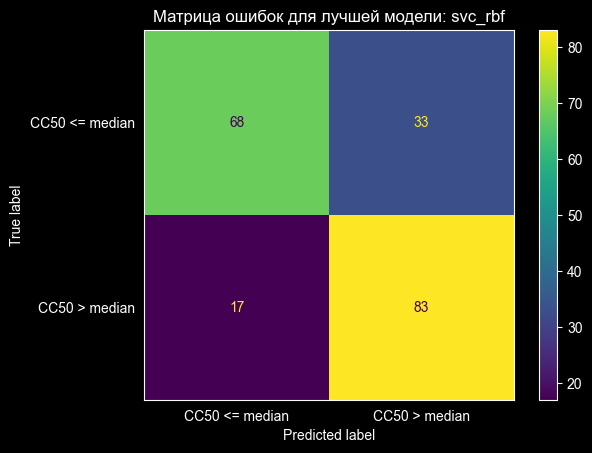

In [107]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "CC50 <= median",
        "CC50 > median",
    ],
)

plt.title(f"Матрица ошибок для лучшей модели: {best_model_name}")
plt.grid(False)
plt.show()

## Важность признаков

Посмотрим, какие признаки оказались наиболее важными для лучшей модели.

График можно построить только для моделей, которые поддерживают атрибут `feature_importances_`.

In [108]:
permutation_result = permutation_importance(
    estimator=best_model,
    X=X_test,
    y=y_test,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame(
        {
            "feature": X_clean.columns,
            "importance_mean": permutation_result.importances_mean,
            "importance_std": permutation_result.importances_std,
        }
    )
    .sort_values(by="importance_mean", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(20)

,feature,importance_mean,importance_std
0,PEOE_VSA6,0.020850,0.006921
1,EState_VSA2,0.017023,0.003483
2,MolLogP,0.015763,0.006993
3,PEOE_VSA14,0.013989,0.005281
4,SMR_VSA10,0.013971,0.007703
5,fr_Imine,0.013946,0.006086
6,FpDensityMorgan3,0.013671,0.004398
7,NumRotatableBonds,0.013428,0.006756
8,PEOE_VSA7,0.012867,0.005857
9,SPS,0.012532,0.002846


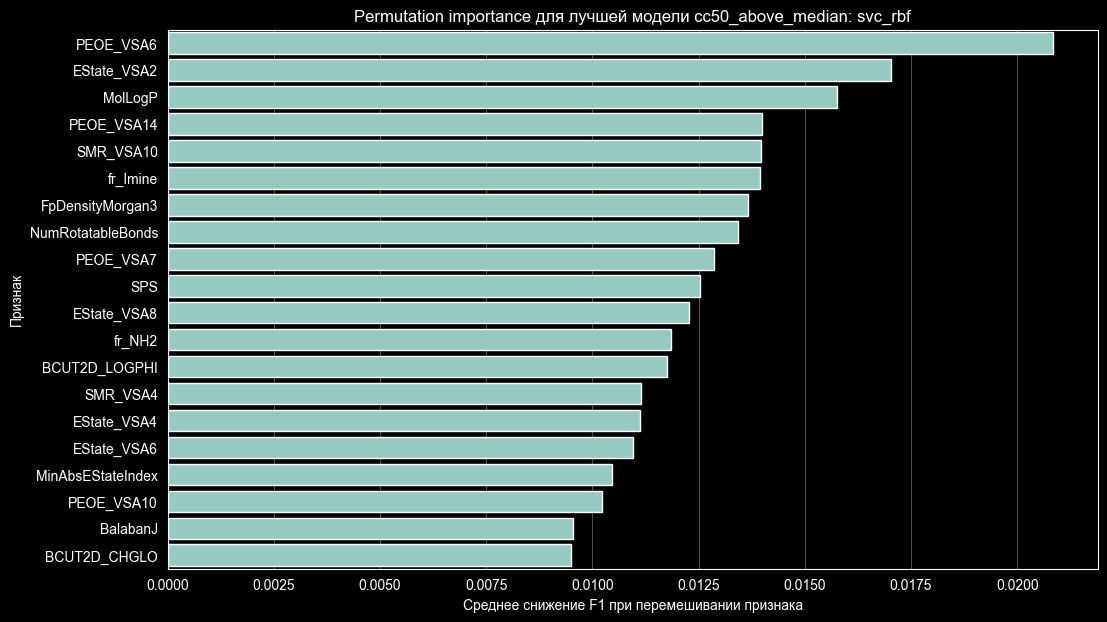

In [109]:
top_importance_df = importance_df.head(20)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_importance_df,
    x="importance_mean",
    y="feature",
)
plt.title(f"Permutation importance для лучшей модели {best_result['target']}: {best_model_name}")
plt.xlabel("Среднее снижение F1 при перемешивании признака")
plt.ylabel("Признак")
plt.grid(axis="x", alpha=0.3)
plt.show()

## Сохранение важности признаков

Сохраним таблицу важности признаков для дальнейшего анализа.

In [110]:
importance_df.to_csv(
    METRICS_DIR / "classification_cc50_median_feature_importance.csv",
    index=False,
)

importance_df.head(20)

,feature,importance_mean,importance_std
0,PEOE_VSA6,0.020850,0.006921
1,EState_VSA2,0.017023,0.003483
2,MolLogP,0.015763,0.006993
3,PEOE_VSA14,0.013989,0.005281
4,SMR_VSA10,0.013971,0.007703
5,fr_Imine,0.013946,0.006086
6,FpDensityMorgan3,0.013671,0.004398
7,NumRotatableBonds,0.013428,0.006756
8,PEOE_VSA7,0.012867,0.005857
9,SPS,0.012532,0.002846


# Итоговый вывод по задаче классификации CC50 > median

В этом ноутбуке была решена задача бинарной классификации для целевой переменной `CC50, mM`.

Целевая переменная была сформирована по правилу:

- `0` -> `CC50, mM` меньше либо равно медианному значению
- `1` -> `CC50, mM` больше медианного значения

Медианное значение `CC50, mM` составило `411.0393`.

Распределение классов получилось практически сбалансированным:

- класс `0`: 502 объекта, доля `0.5015`
- класс `1`: 499 объектов, доля `0.4985`

Так как классы сбалансированы, метрики `accuracy`, `balanced_accuracy` и `F1` можно интерпретировать достаточно уверенно.
При этом основной метрикой сравнения моделей выбран `F1`, так как она учитывает баланс между `precision` и `recall`.

Перед обучением была выполнена предобработка признаков:

- исходное количество признаков: 210
- количество признаков после обработки: 134
- удалено константных признаков: 18
- удалено почти константных признаков: 15
- удалено сильно коррелирующих признаков: 43
- всего удалено признаков: 76

Для сравнения были обучены модели бинарной классификации:

- `DummyClassifier`
- `LogisticRegression`
- `KNN`
- `SVC`
- `RandomForest`
- `ExtraTrees`
- `HistGradientBoosting`
- `CatBoost`

Лучший результат показала модель `svc_rbf`.

Итоговые метрики лучшей модели:

- `Accuracy`: `0.7512`
- `Balanced accuracy`: `0.7516`
- `Precision`: `0.7155`
- `Recall`: `0.8300`
- `F1`: `0.7685`
- `ROC-AUC`: `0.8206`

Модель заметно превосходит базовый `DummyClassifier`, у которого `F1 = 0`, поэтому можно сделать вывод,
что в молекулярных дескрипторах действительно есть полезная информация для разделения соединений по уровню `CC50`.

По отчету классификации видно, что модель лучше находит класс `CC50 > median`:

- для класса `CC50 <= median` -> `precision = 0.80`, `recall = 0.67`, `F1 = 0.73`
- для класса `CC50 > median` -> `precision = 0.72`, `recall = 0.83`, `F1 = 0.77`

Это означает, что модель чаще правильно обнаруживает соединения с `CC50` выше медианы,
но при этом часть объектов с низким `CC50` ошибочно относит к высокому классу.

Матрица ошибок подтверждает этот вывод:

- 68 объектов класса `CC50 <= median` классифицированы верно
- 33 объекта класса `CC50 <= median` ошибочно отнесены к `CC50 > median`
- 83 объекта класса `CC50 > median` классифицированы верно
- 17 объектов класса `CC50 > median` ошибочно отнесены к `CC50 <= median`

Так как лучшая модель `svc_rbf` не имеет встроенного атрибута `feature_importances_`,
то для анализа важности признаков была использована permutation importance.

Наиболее значимыми признаками оказались:

- `PEOE_VSA6`
- `EState_VSA2`
- `MolLogP`
- `PEOE_VSA14`
- `SMR_VSA10`
- `fr_Imine`
- `FpDensityMorgan3`
- `NumRotatableBonds`
- `PEOE_VSA7`
- `SPS`

Эти признаки сильнее всего влияют на качество классификации,
при их перемешивании среднее значение `F1` снижается сильнее всего.

### Итог

Для задачи классификации `CC50, mM > median` лучшей моделью стала `SVC` с RBF-ядром.
Модель показывает устойчивое качество, хорошо отделяет соединения с высоким значением `CC50`
и может быть использована как базовое решение для данной классификационной задачи.